# **Laboratorio 1**

Laura Sanchez Bernal - 202411353

Baruc Jeronimo Triana Bastidas - 202416093

## **Actividades a realizar**

1. **Exploración de los datos:** Utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para conocer el conjunto de datos compartido, determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


datos = pd.read_csv('./data/Datos lab 1.csv', )
datosPrueba = pd.read_csv('./data/Datos Test Lab 1.csv', )

data = datos.copy()
dataPrueba = datosPrueba.copy()

### **Analisis de datos**

In [80]:
dict = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


#### **Clasificacion columnas**

**Cuantitativas_continuas:** presion_media, presion_min, presion_max, presion_desv, humedad_media, humedad_min, humedad_max, humedad_desv, viento_media, viento_min, viento_max, viento_desv, rafaga_media, rafaga_min, rafaga_max, rafaga_desv, viento_norte, viento_este, direccion_viento, temp_max_manana

**Cuantitativas_discretas:** registros_del_dia, anio, dia_del_anio

**Cualitativas_ordinales:** Ninguna

**Cualitativas_nominales:** estacion_anio, mes, sector_viento

Nuestro conjunto de datos está compuesto por 2576 registros (filas) y 27 variables (columnas), principalmente de tipo numérico (23 columnas float64) y 4 columnas de tipo texto (str), correspondientes a variables como fecha y sector_viento.


In [81]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

## **Completitud**

El dataset tiene faltantes distribuidos en todas las columnas. Se calculó el porcentaje de valores faltantes por columna, encontrando que las 27 variables tienen datos nulos, en un rango relativamente uniforme entre 2.4% y 3.7%.

In [ ]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

## **Consistencia**

**Sector_viento:** La columna sector_viento debería tener solo 8 categorías (N, NE, E, SE, S, SO, O, NO) según el diccionario de datos, pero no estan presentando consistencia.

**Estacion_anio:** La columna estacion_anio debería tener solo 4 categorías (invierno, primavera, verano u otoño) según el diccionario de datos, pero no estan presentando consistencia.

In [82]:
data['sector_viento'].value_counts()

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

In [83]:
data['estacion_anio'].value_counts()

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [84]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


## **Validez**

1. **Presion_media**: Al revisar la columna presion_media, se encontro un dato que no tiene sentido, el valor máximo es 9939.9, cuando la presión atmosférica normal está entre 950 y 1050 mbar aproximadamente. Esto se confirma al compararlo con presion_min y presion_max, cuyos máximos sí son razonables (1012.3 y 1013.9). Como la media diaria siempre debería estar entre el mínimo y el máximo del día.

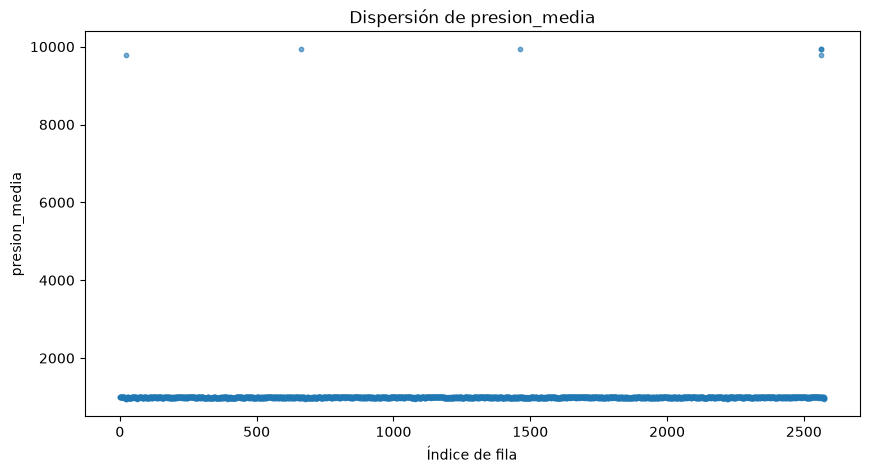

np.int64(6)

In [85]:
plt.figure(figsize=(10,5))
plt.scatter(data.index, data['presion_media'], alpha=0.6, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('presion_media')
plt.title('Dispersión de presion_media')
plt.show()

(data['presion_media'] > 1050).sum()

2. **Humedad_media**: Encontramos que 776 registros (cerca del 30% del dataset) tienen valores menores a 1, como 0.91 o 0.92, mientras que el resto de los datos está en escala de porcentaje, con valores como 76.4 o 89.4. El diagrama de dispersión confirma este problema pues se observan dos bandas de puntos claramente separadas, una entre 40 y 100 y otra pegada a 0. Esto indica que esos 776 registros probablemente se guardaron como proporción (0 a 1) en lugar de porcentaje (0 a 100).

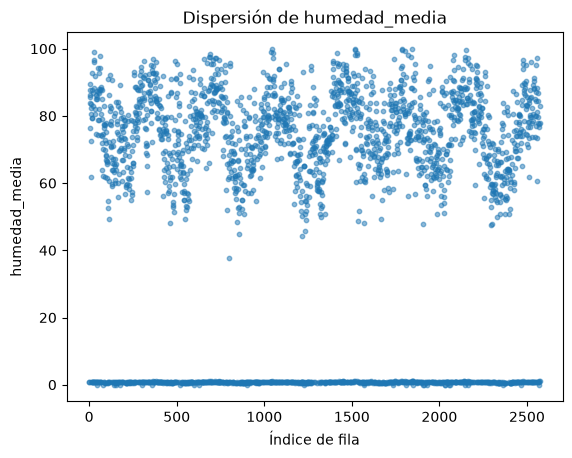

np.int64(776)

In [86]:
plt.scatter(data.index, data['humedad_media'], alpha=0.5, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('humedad_media')
plt.title('Dispersión de humedad_media')
plt.show()

(data['humedad_media'] < 1).sum()

3. **Rafaga_min y viento_norte:** Se encontró un registro con un valor centinela de -9999 en rafaga_min, lo cual no es coherente. Al revisar la fila completa, se identificó que no es un error aislado, la fila presenta múltiples valores irregulares pues en viento_norte el valor es -1250.46 m/s, una magnitud físicamente imposible para el viento.

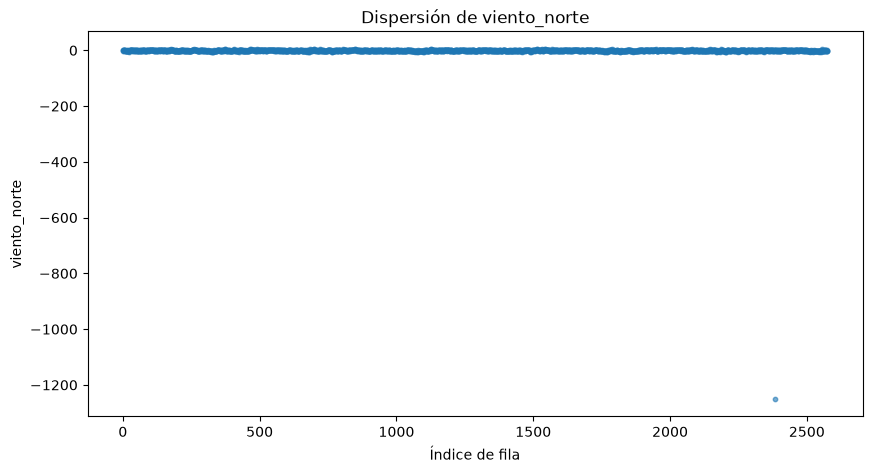

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
2384,2015-07-13,989.8826,988.77,990.94,0.5409,82.5317,60.5,94.6,10.118,NaN,...,-1250.4633,3.5736,179.8363,144.0,2015.0,NaN,verano,July,S,22.26


In [87]:
plt.figure(figsize=(10,5))
plt.scatter(data.index, data['viento_norte'], alpha=0.6, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('viento_norte')
plt.title('Dispersión de viento_norte')
plt.show()

data.loc[data['rafaga_min'] == -9999]


4. **Registros_del_dia:** Se encontraron 4 registros con más de 144 mediciones por día, el máximo esperado según el diccionario de datos

In [88]:
data.loc[data['registros_del_dia'] > 144, ['fecha','registros_del_dia']]

,fecha,registros_del_dia
546,2010-07-01,287.0
547,2010-07-02,145.0
1904,2014-03-20,222.0
1905,2014-03-21,249.0


5. **temp_max_manana:** El valor máximo (63.05°C) parecía un outlier extremo, pero al investigarlo se encontró que corresponde a una fila duplicada en el dataset (ver sección de Unicidad), no a un error de temperatura. Una vez eliminados los duplicados, el rango de la variable queda dentro de valores climáticamente razonables.

In [89]:
data['temp_max_manana'].describe()

count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64

<Axes: >

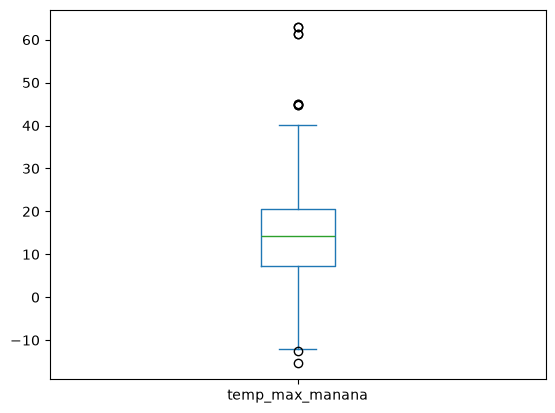

In [90]:
data['temp_max_manana'].plot.box()

## **Unicidad**

Se identificaron 4 pares de filas completamente duplicadas en el dataset con los mismos valores en las 27 columnas (Esto es correspondiente a 8 filas involucradas). Este hallazgo es relevante porque una de las columnas afectadas es temp_max_manana, cuyo valor máximo (63.05°C) inicialmente parecía un outlier, pero en realidad se debía a que el registro estaba duplicado y no a un error real de temperatura.

In [91]:
n_duplicados = int(data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

data[data.duplicated(keep=False)].sort_values('fecha')

Número de registros duplicados: 8


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412


## **Formato automático para el entendimiento de los datos**

In [1]:
from ydata_profiling import ProfileReport

/var/folders/cp/p5kbj9_s7wv6hvd3xffs7nd40000gn/T/ipykernel_82891/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [4]:
profile = ProfileReport(
    data,
    title="Reporte de Análisis Exploratorio",
    explorative=True
)

In [5]:
profile.to_file("reporte_analisis_exploratorio.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 27/27 [00:00<00:00, 215.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------------------------------------------------------------

2. Justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior y de acuerdo con el modelo que van a construir.

In [2]:
from importlib.metadata import version
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Scikit learn: {version('scikit-learn')}")

Versión de Pandas: 2.3.3
Versión de Matplotlib: 3.10.0
Versión de Seaborn: 0.13.2
Versión de Scikit learn: 1.7.2


## **Unicidad**

1. **Filas duplicadas:** 4 filas idénticas en las 27 columnas, es un caso sin ambigüedad. Se conserva solo la primera con drop_duplicates()


In [3]:
n_duplicados = int(data.duplicated().sum())
print(f"Número de registros duplicados: {n_duplicados}")
data = data.drop_duplicates(keep='first')


Número de registros duplicados: 4


## **Consistencia**

1. **Sector_viento, mes y estacion_anio:** Las columnas presentaban muchas variantes distintas para las mismas categorías como mezcla de mayúsculas/minúsculas, español/inglés, abreviado/completo. Por ejemplo, 27 categorías para sector_viento cuando solo deberían existir 8. Aquí el problema es complejo puesto que hay traducción de idioma y formato abreviado, así que se hizo un diccionario de mapeo ya que es la estrategia que el notebook recomienda para "múltiples variantes a unificar". Se usó .replace() en lugar de .map() porque .replace() conserva sin cambios cualquier valor que no esté explícitamente en el diccionario, mientras que .map() lo convertiría en NaN. Esto es más seguro si existiera alguna variante que no detectamos en la exploración inicial, evitando pérdida silenciosa de información.

In [4]:
data['sector_viento'] = data['sector_viento'].str.strip().str.upper()

mapeo_sector_viento_v2 = {
    'NORTH': 'N',
    'NORTE': 'N',

    'SOUTH': 'S',
    'SUR': 'S',

    'EAST': 'E',
    'ESTE': 'E',

    'WEST': 'O',
    'OESTE': 'O',

    'NORTHEAST': 'NE',
    'NORESTE': 'NE',

    'NORTHWEST': 'NO',
    'NOROESTE': 'NO',

    'SOUTHEAST': 'SE',
    'SURESTE': 'SE',

    'SOUTHWEST': 'SO',
    'SUROESTE': 'SO'
}

data['sector_viento'] = data['sector_viento'].replace(mapeo_sector_viento_v2)

print(data['sector_viento'].value_counts())
print(f"\nTotal categorías: {data['sector_viento'].nunique()}")


sector_viento
SO    774
S     580
NE    471
O     328
N     137
E      87
SE     72
NO     52
Name: count, dtype: int64

Total categorías: 8


In [5]:
data['mes'] = data['mes'].str.strip().str.lower()

mapeo_mes_v2 = {
    'january': 'enero', 'jan': 'enero',
    'february': 'febrero', 'feb': 'febrero',
    'march': 'marzo', 'mar': 'marzo',
    'april': 'abril', 'apr': 'abril',
    'may': 'mayo',
    'june': 'junio', 'jun': 'junio',
    'july': 'julio', 'jul': 'julio',
    'august': 'agosto', 'aug': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre',
    'october': 'octubre', 'oct': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre',
}
data['mes'] = data['mes'].replace(mapeo_mes_v2)

print(data['mes'].value_counts())
print(f"\nTotal categorías: {data['mes'].nunique()}")

mes
septiembre    234
enero         230
diciembre     214
marzo         213
noviembre     211
julio         209
agosto        209
mayo          198
octubre       197
febrero       197
junio         192
abril         180
Name: count, dtype: int64

Total categorías: 12


In [6]:
data['estacion_anio'] = data['estacion_anio'].str.strip().str.lower()

mapeo_estacion_anio = {
    'primaveraa': 'primavera', 'primav' : 'primavera', 'spring' : 'primavera',
    'invernio': 'invierno', 'winter': 'invierno',
    'otono': 'otoño', 'autumn': 'otoño', 'fall': 'otoño',
    'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
}
data['estacion_anio'] = data['estacion_anio'].replace(mapeo_estacion_anio)

valores_invalidos = ['inverano', 'estacion_desconocida', 'verano_invierno', 'east']
n_invalidos = data['estacion_anio'].isin(valores_invalidos).sum()
print(f"Valores inválidos convertidos a NaN: {n_invalidos}")
data.loc[data['estacion_anio'].isin(valores_invalidos), 'estacion_anio'] = np.nan

print(data['estacion_anio'].value_counts())
print(f"\nTotal categorías: {data['estacion_anio'].nunique()}")
print(f"Nulos en estacion_anio: {data['estacion_anio'].isna().sum()}")

Valores inválidos convertidos a NaN: 242
estacion_anio
primavera    565
invierno     564
otoño        563
verano       550
Name: count, dtype: int64

Total categorías: 4
Nulos en estacion_anio: 330


## **Validez**

1. **Fila corrupta 2015-07-13**: Afecta varias columnas a la vez con valores imposibles como (-9999, -1250, NaN), y no contamos con una regla que permita reconstruirla. Al no poder corregirla, se elimina para no inventar datos.

In [7]:
fila_corrupta = data[data['rafaga_min'] == -9999].copy()
print(f"Filas corruptas a eliminar: {fila_corrupta.shape[0]}")
data = data[data['rafaga_min'] != -9999]

Filas corruptas a eliminar: 1


2. **Presion_media:** Los valores >1050 son físicamente imposibles, pero al dividirlos entre 10 caen dentro del rango normal, puede ser un error de escritura y no creemos que sea un dato perdido. Usamoa .loc porque es una regla de negocio conocida, aplicable solo a los registros afectados.


In [8]:
mask_presion = (data['presion_media'] > 1050)
print(f"Registros corregidos en presion_media: {mask_presion.sum()}")
data.loc[mask_presion, 'presion_media'] = data.loc[mask_presion, 'presion_media'] / 10


Registros corregidos en presion_media: 5


3. **Humedad_media** Los valores <1 están en escala de proporción (0-1) en vez de porcentaje (0-100). Desidimos multiplicar por 100, pues recupera el dato real. Igual que con presión, es una corrección puntual con regla conocida, no una imputación.

In [9]:
mask_humedad = (data['humedad_media'] < 1)
print(f"Registros corregidos en humedad_media: {mask_humedad.sum()}")
data.loc[mask_humedad, 'humedad_media'] = data.loc[mask_humedad, 'humedad_media'] * 100

Registros corregidos en humedad_media: 775


4. **Registros_del_dia > 144:** Se encontraron 4 registros que superan el máximo lógico de 144 mediciones diarias. Al no poder determinarse la causa exacta del exceso de mediciones y no tratarse de columnas correlacionadas que permitan inferir el valor correcto, como sí pasaba con presión y humedad, se optó por eliminarlos en vez de intentar adivinar cuál sería el conteo correcto.

In [10]:
fuera_rango_registros = data[data['registros_del_dia'] > 144].copy()
print(f"Registros fuera de rango en registros_del_dia: {fuera_rango_registros.shape[0]}")
data = data[data['registros_del_dia'] <= 144]

Registros fuera de rango en registros_del_dia: 4


Se encontraron registros donde el valor mínimo era mayor que el máximo en presión, humedad y viento. Como no es posible determinar cuál de los dos valores es incorrecto, se marcaron ambos como faltantes para que sean tratados posteriormente mediante imputación dentro del pipeline.

In [11]:
print("Presión:", (data['presion_min'] > data['presion_max']).sum())
print("Humedad:", (data['humedad_min'] > data['humedad_max']).sum())
print("Viento:", (data['viento_min'] > data['viento_max']).sum())

mask_presion = data['presion_min'] > data['presion_max']
data.loc[mask_presion, ['presion_min', 'presion_max']] = np.nan

mask_humedad = data['humedad_min'] > data['humedad_max']
data.loc[mask_humedad, ['humedad_min', 'humedad_max']] = np.nan

mask_viento = data['viento_min'] > data['viento_max']
data.loc[mask_viento, ['viento_min', 'viento_max']] = np.nan

Presión: 116
Humedad: 94
Viento: 114


## **Completitud**

La mayoría de las variables presentan valores faltantes. Los registros con temp_max_manana nula se eliminan, ya que esta corresponde a la variable objetivo y no debe imputarse artificialmente. Las filas con fecha nula también se eliminan, dado que no se considera adecuado inventar un valor temporal. Los valores faltantes restantes pertenecen a variables predictoras y serán tratados posteriormente dentro del pipeline del modelo, usando mediana para las variables cuantitativas y moda para las variables categóricas. De esta forma, los valores de imputación se calcularán únicamente con los datos de entrenamiento.

In [12]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

estacion_anio        0.126104
viento_min           0.080723
viento_max           0.076707
presion_min          0.074699
humedad_max          0.071084
presion_max          0.070683
humedad_min          0.068675
temp_max_manana      0.036948
mes                  0.034538
anio                 0.034137
viento_media         0.032530
presion_desv         0.031325
direccion_viento     0.031325
viento_norte         0.031325
rafaga_desv          0.030924
rafaga_media         0.030522
humedad_media        0.029317
rafaga_min           0.028916
presion_media        0.028916
fecha                0.028916
rafaga_max           0.028514
sector_viento        0.028112
viento_desv          0.027309
dia_del_anio         0.026104
viento_este          0.025703
humedad_desv         0.024498
registros_del_dia    0.000000
dtype: float64

In [13]:
cuantitativas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'anio', 'dia_del_anio', 'registros_del_dia'
]

filas_antes = data.shape[0]
data = data.dropna(subset=['temp_max_manana'])
print(f"Filas eliminadas por temp_max_manana nula: {filas_antes - data.shape[0]}")




Filas eliminadas por temp_max_manana nula: 92


In [14]:
cualitativas = ['estacion_anio', 'mes', 'sector_viento']


In [77]:
filas_antes = data.shape[0]
data = data.dropna(subset=['fecha'])
print(f"Filas eliminadas por fecha nula: {filas_antes - data.shape[0]}")

Filas eliminadas por fecha nula: 0


In [78]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

estacion_anio        0.090984
fecha                0.000000
rafaga_min           0.000000
sector_viento        0.000000
mes                  0.000000
dia_del_anio         0.000000
anio                 0.000000
registros_del_dia    0.000000
direccion_viento     0.000000
viento_este          0.000000
viento_norte         0.000000
rafaga_desv          0.000000
rafaga_max           0.000000
rafaga_media         0.000000
presion_media        0.000000
viento_desv          0.000000
viento_max           0.000000
viento_min           0.000000
viento_media         0.000000
humedad_desv         0.000000
humedad_max          0.000000
humedad_min          0.000000
humedad_media        0.000000
presion_desv         0.000000
presion_max          0.000000
presion_min          0.000000
temp_max_manana      0.000000
dtype: float64

## **Resumen de Limpieza:**


In [75]:
print("=== Dimensiones del dataset ===")
print(f"Filas: {data.shape[0]}, Columnas: {data.shape[1]}")

print("\n=== Valores nulos ===")
print(data.isnull().sum()[data.isnull().sum() > 0])
if data.isnull().sum().sum() == 0:
    print("Sin valores nulos")
if data.isnull().sum().sum() > 0:
    print("Los nulos restantes se tratarán dentro del pipeline del modelo")

print("\n=== Duplicados ===")
dup = data.duplicated().sum()
print(f"Filas duplicadas: {dup}")
if dup == 0:
    print("Sin duplicados")

print("\n=== Valores únicos en sector_viento ===")
print(data['sector_viento'].value_counts())

print("\n=== Valores únicos en mes ===")
print(data['mes'].value_counts())

print("\n=== Rango de presion_media ===")
print(f"Min: {data['presion_media'].min()}, Max: {data['presion_media'].max()}")
if data['presion_media'].min() >= 950 and data['presion_media'].max() <= 1050:
    print("presion_media dentro del rango esperado")

print("\n=== Rango de humedad_media ===")
print(f"Min: {data['humedad_media'].min()}, Max: {data['humedad_media'].max()}")
if data['humedad_media'].min() >= 0 and data['humedad_media'].max() <= 100:
    print("humedad_media dentro del rango [0, 100]")

print("\n=== Rango de registros_del_dia ===")
print(f"Min: {data['registros_del_dia'].min()}, Max: {data['registros_del_dia'].max()}")
if data['registros_del_dia'].max() <= 144:
    print("registros_del_dia dentro del máximo lógico 144")
if data.isnull().sum().sum() > 0:
    print("\nLos valores nulos restantes serán tratados dentro del pipeline del modelo.")

=== Dimensiones del dataset ===
Filas: 2418, Columnas: 27

=== Valores nulos ===
estacion_anio    220
dtype: int64
Los nulos restantes se tratarán dentro del pipeline del modelo

=== Duplicados ===
Filas duplicadas: 0
Sin duplicados

=== Valores únicos en sector_viento ===
sector_viento
SO    800
S     541
NE    447
O     307
N     132
E      78
SE     68
NO     45
Name: count, dtype: int64

=== Valores únicos en mes ===
mes
enero         301
septiembre    221
diciembre     202
noviembre     200
marzo         200
julio         199
agosto        197
mayo          186
octubre       183
febrero       182
junio         178
abril         169
Name: count, dtype: int64

=== Rango de presion_media ===
Min: 948.996, Max: 1011.6538

=== Rango de humedad_media ===
Min: 0.565128, Max: 100.0
humedad_media dentro del rango [0, 100]

=== Rango de registros_del_dia ===
Min: 90.0, Max: 144.0
registros_del_dia dentro del máximo lógico 144

Los valores nulos restantes serán tratados dentro del pipeline d

# **Ingenieria de Caracteristicas**

In [18]:
datatransf = data.copy()

## **Escalado de Variables Numericas**

 Las variables numéricas presentan magnitudes diferentes, por lo que el escalamiento se realizará posteriormente dentro del pipeline del modelo, utilizando únicamente la información del conjunto de entrenamiento.

In [19]:
columnas_a_escalar = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'dia_del_anio'
]



## **Codificacion de Variables Categoricas**

Las variables sector_viento, mes y estacion_anio son categóricas nominales, por lo que se utilizará One-Hot Encoding. Esta transformación se realizará posteriormente dentro del pipeline del modelo, de manera que el codificador se ajuste únicamente con los datos de entrenamiento y luego se aplique de la misma forma a los datos de prueba.

## **Creación de nuevas variables**

1. **Amplitud de presión, humedad y viento (amplitud_presion, amplitud_humedad, amplitud_viento):** estas variables capturan la variabilidad diaria de cada medición permitiendo identificar la diferencia entre el máximo y el mínimo del día, esta información no está explícita en las columnas originales. Un día con presión estable (amplitud baja) y un día con presión muy cambiante (amplitud alta) pueden tener la misma presion_media, pero representan condiciones climáticas muy distintas. La amplitud permite capturar esa diferencia, lo cual puede ser relevante para predecir temp_max_manana.

In [20]:
datatransf['amplitud_presion'] = data['presion_max'] - data['presion_min']

datatransf['amplitud_humedad'] = data['humedad_max'] - data['humedad_min']

datatransf['amplitud_viento'] = data['viento_max'] - data['viento_min']

print("Estadísticas de las nuevas variables:")
print(datatransf[['amplitud_presion', 'amplitud_humedad', 'amplitud_viento']].describe().round(2))

Estadísticas de las nuevas variables:
       amplitud_presion  amplitud_humedad  amplitud_viento
count           2103.00           2095.00          2073.00
mean               5.73             48.86             7.29
std                3.80             28.44             6.27
min                0.90              0.00             0.00
25%                3.10             26.69             3.22
50%                4.88             42.26             4.84
75%                7.30             74.54             9.14
max               65.51             99.46            44.06


2. **Velocidad resultante del viento(velocidad_resultante):** El dataset registra el viento descompuesto en dos componentes perpendiculares (viento_norte y viento_este), pero ninguna de las dos por separado representa la intensidad real del viento, un valor de viento_norte = 0 no significa que no hay viento, solo que el viento no sopla en esa dirección. Se calcula la magnitud del vector resultante (teorema de Pitágoras: √(norte² + este²)) para obtener una sola variable que sí refleja la fuerza total del viento, independientemente de su dirección.

In [21]:
datatransf['velocidad_resultante'] = (data['viento_norte']**2 + data['viento_este']**2) ** 0.5

print("Estadísticas de las nuevas variables:")
print(datatransf[['velocidad_resultante']].describe().round(2))

Estadísticas de las nuevas variables:
       velocidad_resultante
count               2201.00
mean                   1.74
std                    1.12
min                    0.00
25%                    0.88
50%                    1.53
75%                    2.39
max                    7.63


# **Resumen final del dataset transformado**

El dataset queda preparado a nivel de calidad y construcción de características. Los valores faltantes restantes, el escalamiento de variables numéricas y la codificación de variables categóricas serán tratados posteriormente dentro del pipeline del modelo, utilizando únicamente los datos de entrenamiento para ajustar dichas transformaciones.

In [22]:
datatransf = datatransf.drop(columns=['fecha'])
print("=== Dataset transformado (datatransf) ===")
print(f"Filas: {datatransf.shape[0]}, Columnas: {datatransf.shape[1]}")
print("\nTipos de datos:")
print(datatransf.dtypes)
print("\nValores nulos:")
print(datatransf.isnull().sum()[datatransf.isnull().sum() > 0])
print("\nPrimeras filas:")

datatransf.head()

=== Dataset transformado (datatransf) ===
Filas: 2328, Columnas: 30

Tipos de datos:
presion_media           float64
presion_min             float64
presion_max             float64
presion_desv            float64
humedad_media           float64
humedad_min             float64
humedad_max             float64
humedad_desv            float64
viento_media            float64
viento_min              float64
viento_max              float64
viento_desv             float64
rafaga_media            float64
rafaga_min              float64
rafaga_max              float64
rafaga_desv             float64
viento_norte            float64
viento_este             float64
direccion_viento        float64
registros_del_dia       float64
anio                    float64
dia_del_anio            float64
estacion_anio            object
mes                      object
sector_viento            object
temp_max_manana         float64
amplitud_presion        float64
amplitud_humedad        float64
amplitud_viento    

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,amplitud_presion,amplitud_humedad,amplitud_viento,velocidad_resultante
0,999.1456,996.50,1000.87,1.3993,91.0860,0.875000,94.8,1.7650,0.7786,0.05,...,2009.0,1.0,invierno,enero,S,-2.12,4.37,93.925,1.509641,0.362487
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,0.22,...,2009.0,2.0,invierno,julio,NE,-0.82,4.72,9.700,3.650000,0.564057
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,0.12,...,2009.0,3.0,invierno,enero,SO,-0.63,9.44,45.510,3.520000,0.875522
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,0.54,...,2009.0,4.0,invierno,enero,SO,-1.44,7.81,NaN,1.914415,1.534270
6,993.5064,991.50,998.41,1.8001,85.6597,80.800000,93.4,3.1011,0.7225,0.08,...,2009.0,7.0,invierno,enero,S,-4.06,6.91,12.600,1.057109,0.591104


# **Conclusion**

En esta etapa se preparó el dataset meteorológico para continuar con la construcción de los modelos. A partir de los problemas encontrados durante la exploración se realizaron correcciones relacionadas con unicidad, consistencia, validez y completitud.

Hablando de unicidad se eliminaron 4 registros duplicados. Para mejorar la consistencia se normalizaron las categorías de sector_viento, mes y estacion_anio; los valores de estacion_anio que no podían asociarse de manera confiable con una estación se marcaron como faltantes.

Por otra parte en la validez, se eliminó una fila que contenía varios valores físicamente imposibles y 4 registros cuyo número de mediciones diarias superaba el máximo de 144. También se corrigieron 5 registros de presion_media que presentaban un problema de escala y 775 registros de humedad_media almacenados como proporción en lugar de porcentaje. Adicionalmente, se encontraron casos donde el mínimo era mayor que el máximo en presión, humedad y viento. Como no era posible determinar cuál de los valores era incorrecto, ambos se marcaron como faltantes para tratarlos posteriormente.

Para la completitud, se eliminaron los registros sin temp_max_manana, ya que esta es la variable objetivo, y aquellos sin fecha. Los demás valores faltantes se conservaron para ser imputados posteriormente dentro del pipeline del modelo, evitando calcular medianas o modas utilizando información del conjunto de prueba.

Finalmente se crearon cuatro nuevas características: amplitud_presion, amplitud_humedad, amplitud_viento y velocidad_resultante, con el objetivo de representar información adicional sobre la variación diaria y la intensidad del viento. La variable fecha se retiró del conjunto final debido a que su información temporal ya está representada por otras variables. El escalamiento, la imputación restante y la codificación de las variables categóricas se realizarán posteriormente dentro del pipeline utilizando los datos de entrenamiento.


# **Cronstruccion de Modelos**

Utilizando la métrica RMSE para analizar el desempeño del modelo y con el uso de pipelines.

## Separación de variables y conjuntos de entrenamiento/prueba

Se separa la variable objetivo temp_max_manana de las variables predictoras. Luego se divide el conjunto de datos en entrenamiento y prueba utilizando test_size=0.25 y random_state=42, como se indica en el enunciado del laboratorio.

In [23]:
from sklearn.model_selection import train_test_split

X = datatransf.drop(columns=['temp_max_manana'])
y = datatransf['temp_max_manana']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1746, 29)
X_test: (582, 29)
y_train: (1746,)
y_test: (582,)


## Modelo 1: Regresión lineal con variables originales

Como modelo base se utiliza una regresión lineal con las variables originales del dataset. Las cuatro variables creadas durante la ingeniería de características no se incluyen en este primer modelo.

Los valores faltantes de las variables numéricas se imputan con la mediana y posteriormente se escalan. Para las variables categóricas se utiliza imputación con la moda y One-Hot Encoding. Estas transformaciones se realizan dentro de un pipeline para que sus parámetros se calculen únicamente utilizando los datos de entrenamiento.

### Selección de variables para el modelo base

Para tener un punto de comparación, el primer modelo se construye únicamente con las variables originales del dataset. Las cuatro variables creadas en la etapa de ingeniería de características se excluyen temporalmente de este modelo.

La idea es usar este modelo como referencia y luego comparar si la incorporación de las nuevas variables realmente mejora el desempeño de la regresión.

In [24]:
variables_nuevas = [
    'amplitud_presion',
    'amplitud_humedad',
    'amplitud_viento',
    'velocidad_resultante'
]

X_train_m1 = X_train.drop(columns=variables_nuevas)
X_test_m1 = X_test.drop(columns=variables_nuevas)

print("X_train Modelo 1:", X_train_m1.shape)
print("X_test Modelo 1:", X_test_m1.shape)

X_train Modelo 1: (1746, 25)
X_test Modelo 1: (582, 25)



Como las variables requieren tratamientos distintos según su tipo, se separan las variables numéricas de las categóricas.

Las variables numéricas serán imputadas y escaladas, mientras que estacion_anio, mes y sector_viento se tratarán como variables categóricas nominales mediante One-Hot Encoding.

In [25]:
categoricas_m1 = ['estacion_anio', 'mes', 'sector_viento']

numericas_m1 = [
    columna for columna in X_train_m1.columns
    if columna not in categoricas_m1
]

print("Variables numéricas:", len(numericas_m1))
print("Variables categóricas:", len(categoricas_m1))

Variables numéricas: 22
Variables categóricas: 3


### Preprocesamiento del Modelo 1

El preprocesamiento se realiza dentro de un pipeline para evitar utilizar información del conjunto de prueba durante el ajuste de las transformaciones.

Para las variables numéricas se utiliza imputación con la mediana, ya que varias variables presentan valores extremos y esta medida es menos sensible a ellos. Después se aplica StandardScaler para llevar las variables a una escala comparable.

Para las variables categóricas se utiliza imputación con la categoría más frecuente y posteriormente One-Hot Encoding, debido a que estas variables son nominales y no existe un orden natural entre sus categorías.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression


pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocesamiento_m1 = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numericas_m1),
        ('cat', pipeline_categorico, categoricas_m1)
    ]
)

In [27]:
modelo_1 = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento_m1),
    ('regresion', LinearRegression())
])

### Entrenamiento y evaluación del Modelo 1

Se entrena el pipeline utilizando únicamente el conjunto de entrenamiento. Después se generan predicciones sobre el conjunto de prueba para evaluar qué tan bien generaliza el modelo sobre datos que no fueron utilizados durante el ajuste.

Para medir el desempeño se utilizan RMSE, MAE y R². El RMSE y el MAE permiten medir el error de las predicciones en las mismas unidades de la temperatura, mientras que R² indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

modelo_1.fit(X_train_m1, y_train)

predicciones_m1 = modelo_1.predict(X_test_m1)

rmse_m1 = np.sqrt(mean_squared_error(y_test, predicciones_m1))
mae_m1 = mean_absolute_error(y_test, predicciones_m1)
r2_m1 = r2_score(y_test, predicciones_m1)

print(f"RMSE Modelo 1: {rmse_m1:.4f}")
print(f"MAE Modelo 1: {mae_m1:.4f}")
print(f"R² Modelo 1: {r2_m1:.4f}")


RMSE Modelo 1: 6.8738
MAE Modelo 1: 5.2532
R² Modelo 1: 0.4397


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### Resultados del Modelo 1

El primer modelo obtuvo un RMSE de 6.8738 y un MAE de 5.2532. Esto indica que todavía existe una diferencia considerable entre las temperaturas reales y las estimadas por el modelo.

El R² obtenido fue de 0.4397, por lo que el modelo logra explicar aproximadamente el 44% de la variabilidad de temp_max_manana. Estos resultados se toman como referencia para evaluar si la incorporación de las variables creadas durante la ingeniería de características permite mejorar la capacidad predictiva del modelo. Ademas aparecen unos warnings, pero con ayuda de la Inteligencia Artifical y el uso de prints durante el proceso de entrenamiento, se identifico que estos warnings no afectan de manera directa los resultados, ni la eficiencia del modelo

## Modelo 2: Regresión lineal con ingeniería de características

Para el segundo modelo se incorporan las cuatro variables creadas durante la etapa de ingeniería de características: amplitud_presion, amplitud_humedad, amplitud_viento y velocidad_resultante.

Se mantiene la misma estrategia de imputación, escalamiento y codificación utilizada en el Modelo 1. De esta manera, la comparación permite analizar principalmente si las nuevas características aportan información útil para predecir temp_max_manana.

In [29]:
X_train_m2 = X_train.copy()
X_test_m2 = X_test.copy()

print("X_train Modelo 2:", X_train_m2.shape)
print("X_test Modelo 2:", X_test_m2.shape)

X_train Modelo 2: (1746, 29)
X_test Modelo 2: (582, 29)


### Identificación de variables numéricas y categóricas

En este modelo se mantienen las mismas tres variables categóricas del modelo anterior. Las cuatro características nuevas son numéricas, por lo que reciben el mismo tratamiento de imputación y escalamiento que las demás variables cuantitativas.

In [30]:
categoricas_m2 = ['estacion_anio', 'mes', 'sector_viento']

numericas_m2 = [
    columna for columna in X_train_m2.columns
    if columna not in categoricas_m2
]

print("Variables numéricas:", len(numericas_m2))
print("Variables categóricas:", len(categoricas_m2))

Variables numéricas: 26
Variables categóricas: 3


### Preprocesamiento del Modelo 2

Se aplica el mismo tratamiento del modelo base para mantener una comparación consistente. Los valores faltantes numéricos se imputan con la mediana y posteriormente se escalan con StandardScaler. Las variables categóricas se imputan con la categoría más frecuente y se codifican mediante One-Hot Encoding.

Todas estas transformaciones permanecen dentro del pipeline para que sean ajustadas únicamente con el conjunto de entrenamiento.

In [31]:
preprocesamiento_m2 = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numericas_m2),
        ('cat', pipeline_categorico, categoricas_m2)
    ]
)

In [32]:
modelo_2 = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento_m2),
    ('regresion', LinearRegression())
])

### Entrenamiento y evaluación del Modelo 2

El segundo modelo se entrena sobre el mismo conjunto de entrenamiento y se evalúa sobre las mismas observaciones de prueba utilizadas en el Modelo 1. Esto permite comparar directamente ambos modelos mediante RMSE, MAE y R².

In [33]:
modelo_2.fit(X_train_m2, y_train)

predicciones_m2 = modelo_2.predict(X_test_m2)

rmse_m2 = np.sqrt(mean_squared_error(y_test, predicciones_m2))
mae_m2 = mean_absolute_error(y_test, predicciones_m2)
r2_m2 = r2_score(y_test, predicciones_m2)

print(f"RMSE Modelo 2: {rmse_m2:.4f}")
print(f"MAE Modelo 2: {mae_m2:.4f}")
print(f"R² Modelo 2: {r2_m2:.4f}")

RMSE Modelo 2: 6.8168
MAE Modelo 2: 5.1721
R² Modelo 2: 0.4489


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### Resultados del Modelo 2

El Modelo 2 obtuvo un RMSE de 6.8168, un MAE de 5.1721 y un R² de 0.4489.

Al comparar estos resultados con el Modelo 1 se observa una mejora ligera en las tres métricas. La disminución del RMSE y del MAE indica una reducción en el error de predicción, mientras que el aumento del R² muestra que el modelo logra explicar una proporción ligeramente mayor de la variabilidad de temp_max_manana.

Esto sugiere que las variables creadas durante la ingeniería de características aportan información útil, aunque la mejora obtenida es limitada.

## Comparación de modelos

Para comparar el desempeño de los dos modelos se utilizan las métricas RMSE, MAE y R² sobre el mismo conjunto de prueba.

En RMSE y MAE, valores menores indican un mejor desempeño porque representan un menor error de predicción. En R², un valor mayor indica que el modelo logra explicar una mayor proporción de la variabilidad de la temperatura máxima del día siguiente.

In [34]:
resultados_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'RMSE': [rmse_m1, rmse_m2],
    'MAE': [mae_m1, mae_m2],
    'R2': [r2_m1, r2_m2]
})

resultados_modelos

,Modelo,RMSE,MAE,R2
0,Modelo 1,6.873814,5.253200,0.439667
1,Modelo 2,6.816806,5.172138,0.448923


### Selección del mejor modelo

El Modelo 2 presenta el mejor desempeño entre los dos modelos evaluados. Su RMSE y MAE son ligeramente menores que los obtenidos por el Modelo 1, mientras que su R² es mayor.

Aunque la diferencia entre ambos modelos no es grande, el Modelo 2 obtiene mejores resultados en las tres métricas. Por esta razón se selecciona como el mejor modelo para continuar con el análisis.

La comparación también muestra que las variables creadas durante la ingeniería de características aportaron una mejora al modelo, aunque su efecto sobre el desempeño fue limitado.

## Validación de supuestos de la regresión lineal

Antes de interpretar los coeficientes del Modelo 2 se revisan algunos de los supuestos principales de la regresión lineal. El análisis se realiza sobre los residuos obtenidos en el conjunto de prueba.

Se revisará principalmente si los residuos presentan un comportamiento aproximadamente aleatorio, si mantienen una varianza relativamente constante y si su distribución es razonablemente cercana a una normal.

In [35]:
residuos_m2 = y_test - predicciones_m2

### Residuos frente a valores predichos

Este gráfico permite observar si los errores presentan algún patrón respecto a las predicciones. 

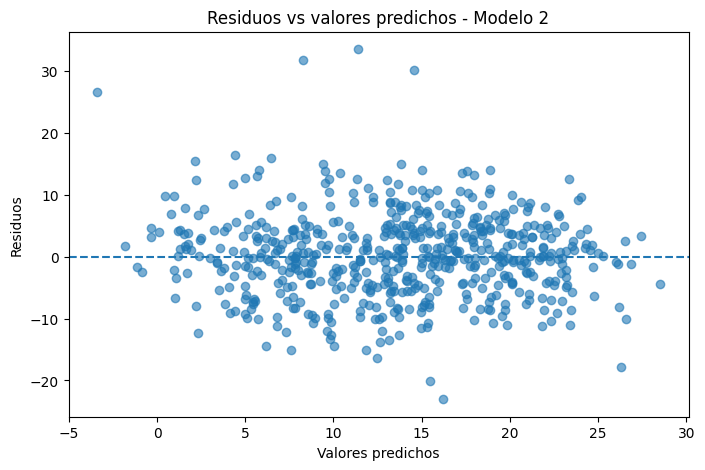

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(predicciones_m2, residuos_m2, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs valores predichos - Modelo 2')
plt.show()

Los residuos se encuentran distribuidos alrededor de cero y no se observa un patrón o tendencia claramente definida con respecto a los valores predichos. Esto sugiere que el supuesto de linealidad es razonablemente adecuado para el modelo. Sin embargo, se observan algunos residuos de magnitud bastante grande y una dispersión que no es completamente uniforme.

### Distribución de los residuos

Se analiza la distribución de los residuos para observar si presenta una forma aproximadamente normal.

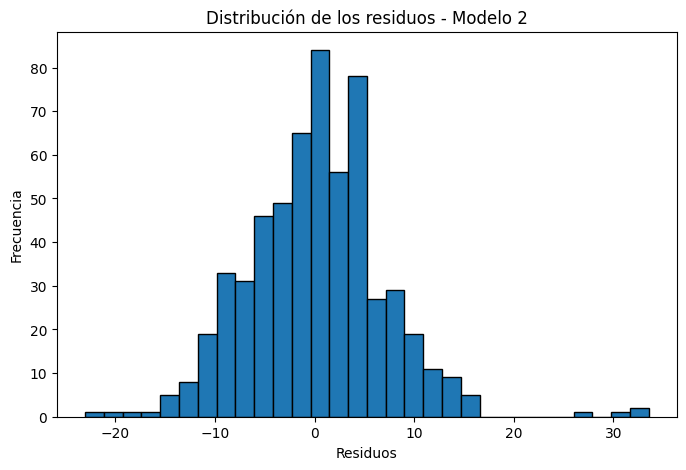

In [40]:
plt.figure(figsize=(8,5))
plt.hist(residuos_m2, bins=30, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de los residuos - Modelo 2')
plt.show()

La mayoría de los residuos se concentra alrededor de cero, Sin embargo, se observan algunos valores extremos, especialmente en el lado positivo, que generan cierta asimetría

### Revisión de la varianza de los residuos

Para revisar si la dispersión de los errores se mantiene aproximadamente constante, se observa la magnitud absoluta de los residuos frente a los valores predichos.

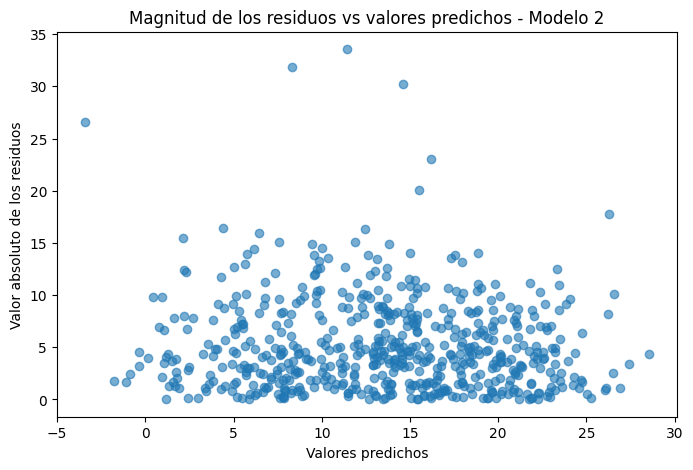

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(predicciones_m2, np.abs(residuos_m2), alpha=0.6)
plt.xlabel('Valores predichos')
plt.ylabel('Valor absoluto de los residuos')
plt.title('Magnitud de los residuos vs valores predichos - Modelo 2')
plt.show()

No se observa un patrón de aumento o disminución claramente definido en la magnitud de los residuos a medida que cambian los valores predichos. Por lo tanto, visualmente la varianza de los residuos puede considerarse aproximadamente constante, aunque el supuesto de homocedasticidad no se cumple de manera perfecta.

## Interpretación de los coeficientes del mejor modelo

Después de revisar los supuestos de la regresión lineal, se analizan los coeficientes obtenidos por el Modelo 2. El signo de cada coeficiente permite observar si una variable se relaciona de manera positiva o negativa con la temperatura máxima del día siguiente.

Algo relevante a mencionar es que debido a que las variables numéricas fueron estandarizadas dentro del pipeline, sus coeficientes pueden compararse de manera más directa entre sí.

### Obtención de los coeficientes del modelo

El pipeline transforma las variables categóricas mediante One-Hot Encoding, por lo que el número de variables que finalmente recibe la regresión es mayor al número de columnas originales.

Para interpretar correctamente los coeficientes, primero se recuperan los nombres de las variables después del preprocesamiento y luego se relacionan con los coeficientes aprendidos por la regresión lineal.

In [42]:
nombres_variables_m2 = modelo_2.named_steps['preprocesamiento'].get_feature_names_out()

coeficientes_m2 = modelo_2.named_steps['regresion'].coef_

print("Número de variables transformadas:", len(nombres_variables_m2))
print("Número de coeficientes:", len(coeficientes_m2))

Número de variables transformadas: 47
Número de coeficientes: 47


In [44]:
tabla_coeficientes = pd.DataFrame({
    'Variable': nombres_variables_m2,
    'Coeficiente': coeficientes_m2
})

tabla_coeficientes['cambio_absoluto'] = tabla_coeficientes['Coeficiente'].abs()

tabla_coeficientes = tabla_coeficientes.sort_values(
    by='cambio_absoluto',
    ascending=False
)

tabla_coeficientes.head(15)

,Variable,Coeficiente,cambio_absoluto
33,cat__mes_julio,4.081891,4.081891
7,num__humedad_desv,3.692561,3.692561
30,cat__mes_diciembre,-2.975748,2.975748
34,cat__mes_junio,2.734414,2.734414
29,cat__mes_agosto,2.178892,2.178892
25,num__velocidad_resultante,-2.083634,2.083634
15,num__rafaga_desv,-1.984404,1.984404
44,cat__sector_viento_S,-1.902347,1.902347
21,num__dia_del_anio,1.894552,1.894552
35,cat__mes_marzo,-1.642951,1.642951


### Interpretación de los coeficientes

Los coeficientes permiten observar la dirección y magnitud de la relación que cada variable tiene con temp_max_manana, manteniendo constantes las demás variables incluidas en el modelo.

Entre los coeficientes de mayor magnitud se encuentran algunas categorías relacionadas con el mes del año, así como humedad_desv, velocidad_resultante, rafaga_desv y dia_del_anio. Esto muestra que tanto las condiciones meteorológicas como la componente temporal tienen un papel importante en la predicción.

También se observa que velocidad_resultante, una de las variables creadas durante la ingeniería de características, aparece entre los coeficientes de mayor magnitud. Esto es consistente con la ligera mejora obtenida por el Modelo 2 frente al modelo base.

# Calculo del intercepto

In [45]:
intercepto_m2 = modelo_2.named_steps['regresion'].intercept_

print(f"Intercepto del Modelo 2: {intercepto_m2:.4f}")

Intercepto del Modelo 2: 13.5814


# Análisis de resultados (Respuestas a preguntas)

## 1. Coeficientes obtenidos en el mejor modelo

El mejor modelo fue el Modelo 2, correspondiente a una regresión lineal que incorpora las variables creadas durante la ingeniería de características.

El intercepto obtenido fue de 13.5814. Entre los coeficientes de mayor magnitud se encuentran mes_julio, humedad_desv, mes_diciembre, mes_junio, mes_agosto, velocidad_resultante, rafaga_desv, sector_viento_S y dia_del_anio.

Los coeficientes positivos indican que, manteniendo constantes las demás variables, el aumento o presencia de esa característica se asocia con un aumento en la temperatura máxima predicha. Los coeficientes negativos indican una asociación en sentido contrario.

## 2. Comparación del rendimiento de los modelos

A partir de la tabla comparativa, el Modelo 2 presenta el mejor rendimiento sobre el conjunto de prueba.

El Modelo 1 obtuvo un RMSE de 6.8738, un MAE de 5.2532 y un R² de 0.4397. Por otro lado, el Modelo 2 obtuvo un RMSE de 6.8168, un MAE de 5.1721 y un R² de 0.4489.

El Modelo 2 mejora ligeramente las tres métricas: presenta menores valores de RMSE y MAE, lo que indica un menor error de predicción, y un R² mayor, lo que significa que logra explicar una proporción ligeramente mayor de la variabilidad de temp_max_manana.

Aunque la mejora no es grande, los resultados sugieren que las variables creadas durante la ingeniería de características aportan información útil al modelo.

## 3. Variables con mayor aporte e interpretación

Entre las variables con coeficientes de mayor magnitud aparecen variables temporales, como algunas categorías de mes y dia_del_anio, así como variables meteorológicas relacionadas con humedad, viento y ráfagas.

También aparece velocidad_resultante, una de las variables creadas durante la ingeniería de características, entre los coeficientes de mayor magnitud. Esto indica que representar conjuntamente las componentes norte y este del viento aporta información útil para la predicción.

Desde el contexto del problema, estos resultados sugieren que tanto la época del año como las condiciones de humedad y viento están relacionadas con la temperatura máxima del día siguiente.

## 4. Representación matemática de la regresión lineal

De forma general, el modelo puede escribirse como:

y = beta_0 + beta_1 * X_1 + beta_2 * X_2 + ... beta_2 * X_p

donde:

- y corresponde a la predicción de temp_max_manana.
- beta_0 es el intercepto del modelo.
- beta_1, beta_2, beta_p son los coeficientes aprendidos.
- X_1, X_2, X_p representan las variables predictoras después del preprocesamiento.

En el Modelo 2 se obtuvo un intercepto (beta_0) de 13.5814. A partir de este valor, cada coeficiente aumenta o disminuye la predicción dependiendo del valor de la variable correspondiente.

Los coeficientes se estiman buscando la recta o hiperplano que minimiza la diferencia entre los valores reales y los valores predichos. En este caso se utilizó LinearRegression de Scikit-Learn dentro de un pipeline que integra el preprocesamiento y el entrenamiento, todo esto con el fin de saber cuales variables afectan de manera mas directa nuestra variable objetivo (y).

## 5. Posibles sesgos en el ciclo de Machine Learning

Los resultados del modelo pueden verse afectados por diferentes tipos de sesgo presentes en los datos o en el proceso de construcción del modelo.

Uno de ellos es el sesgo de selección, que puede aparecer si los datos utilizados para entrenar el modelo no representan adecuadamente todas las condiciones meteorológicas posibles. Por ejemplo, si existen más observaciones de ciertas épocas del año o determinados tipos de clima, el modelo podría aprender mejor esos casos y presentar peor desempeño en situaciones menos representadas.

Otro posible problema es el sesgo de medición, ya que algunas variables presentan errores de escala, valores fuera de rango, categorías inconsistentes y registros faltantes. Aunque durante la preparación se corrigieron varios de estos problemas, los errores presentes en las mediciones originales pueden afectar las relaciones aprendidas por el modelo.


# Predicción sobre los datos no etiquetados

Finalmente, se utiliza el Modelo 2

Antes de realizar las predicciones se aplican a estas observaciones las mismas correcciones determinísticas utilizadas durante la preparación de los datos de entrenamiento. Los valores faltantes restantes, el escalamiento y la codificación de variables categóricas son tratados automáticamente por el pipeline previamente ajustado.

In [46]:
test_final = dataPrueba.copy()

print("Dimensiones originales del test:", test_final.shape)

Dimensiones originales del test: (364, 26)


### Preparación de las variables categóricas

Las variables sector_viento, mes y estacion_anio se normalizan utilizando los mismos diccionarios de equivalencias definidos durante la preparación de los datos de entrenamiento.

In [47]:
test_final['sector_viento'] = test_final['sector_viento'].str.strip().str.upper()
test_final['sector_viento'] = test_final['sector_viento'].replace(mapeo_sector_viento_v2)

test_final['mes'] = test_final['mes'].str.strip().str.lower()
test_final['mes'] = test_final['mes'].replace(mapeo_mes_v2)

test_final['estacion_anio'] = test_final['estacion_anio'].str.strip().str.lower()
test_final['estacion_anio'] = test_final['estacion_anio'].replace(mapeo_estacion_anio)

test_final.loc[
    test_final['estacion_anio'].isin(valores_invalidos),
    'estacion_anio'
] = np.nan

### Corrección de valores fuera de dominio

Se aplican las mismas reglas utilizadas en entrenamiento para corregir errores de escala y relaciones inválidas entre mínimos y máximos. En los casos donde no es posible reconstruir un valor de manera confiable, este se marca como faltante para que el pipeline realice la imputación.

In [48]:
mask_presion_test = test_final['presion_media'] > 1050
test_final.loc[mask_presion_test, 'presion_media'] = (
    test_final.loc[mask_presion_test, 'presion_media'] / 10
)

mask_humedad_test = test_final['humedad_media'] < 1
test_final.loc[mask_humedad_test, 'humedad_media'] = (
    test_final.loc[mask_humedad_test, 'humedad_media'] * 100
)

test_final.loc[
    test_final['registros_del_dia'] > 144,
    'registros_del_dia'
] = np.nan

In [49]:
mask_presion_test = test_final['presion_min'] > test_final['presion_max']
test_final.loc[
    mask_presion_test,
    ['presion_min', 'presion_max']
] = np.nan

mask_humedad_test = test_final['humedad_min'] > test_final['humedad_max']
test_final.loc[
    mask_humedad_test,
    ['humedad_min', 'humedad_max']
] = np.nan

mask_viento_test = test_final['viento_min'] > test_final['viento_max']
test_final.loc[
    mask_viento_test,
    ['viento_min', 'viento_max']
] = np.nan

### Creación de las características utilizadas por el Modelo 2

Como el modelo seleccionado utiliza las variables creadas durante la ingeniería de características, estas se calculan también sobre el conjunto de datos no etiquetado utilizando exactamente las mismas expresiones.

In [51]:
test_final['amplitud_presion'] = (
    test_final['presion_max'] - test_final['presion_min']
)

test_final['amplitud_humedad'] = (
    test_final['humedad_max'] - test_final['humedad_min']
)

test_final['amplitud_viento'] = (
    test_final['viento_max'] - test_final['viento_min']
)

test_final['velocidad_resultante'] = (
    test_final['viento_norte']**2 +
    test_final['viento_este']**2
) ** 0.5

test_final = test_final.drop(columns=['fecha'])

In [53]:
print("Columnas esperadas por el modelo:", X_train_m2.shape[1])
print("Columnas disponibles en test:", test_final.shape[1])


Columnas esperadas por el modelo: 29
Columnas disponibles en test: 29


In [54]:
test_final = test_final[X_train_m2.columns]

### Generación de predicciones

Como ya se preparo todo el conjunto de datos de la proba, se va a proceder a utilizar el Modelo 2 para estimar temp_max_manana.


In [55]:
predicciones_finales = modelo_2.predict(test_final)

print("Número de predicciones:", len(predicciones_finales))
print("Primeras predicciones:")
print(predicciones_finales[:5])

Número de predicciones: 364
Primeras predicciones:
[1.2678197  3.6130833  4.15283517 6.95954815 2.00090041]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [56]:
datos_salida = dataPrueba.copy()

datos_salida['temp_max_manana'] = predicciones_finales

datos_salida.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,1.267820
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,3.613083
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,4.152835
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,6.959548
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,2.000900


In [57]:
datos_salida.to_csv(
    './data/Datos Test Lab 1.csv',
    index=False
)

El archivo final conserva las observaciones originales del conjunto de prueba y agrega la columna temp_max_manana con las predicciones generadas por el Modelo 2.

# **Uso de herramientas de IA generativa**

# Declaración del uso
1. Se utilizó Claude (Anthropic) como apoyo durante el desarrollo del laboratorio de exploración y guia. Los tipos de uso fueron: ayuda conceptual (explicación de conceptos como escalado de variables y multicolinealidad), depuración de errores técnicos (entorno de Python, dependencias, errores de ejecución en el notebook) y apoyo en la redacción técnica del reporte.

Prompts utilizados

Entre los prompts principales que influyeron directamente en el resultado entregado se encuentran:
1. "A clarar dentro del contexto meteorologico si las variables estan bien categorizadas".
2. "Verifica si el analisis y presentacion de los errores es completo y cumple con lo establecido".
3. "Explicame el codigo que se encuentra en P4_Regresion lineal".
4. "Identifica en las cualitativas nominales los valores asignados y si cumplen con lo establecido en el diccionerio, dime todos los valores existentes"
5. "Verifica que este completo el trabajo que se propuso".
 

Análisis crítico del resultado

- ¿Qué partes del contenido generado fueron correctas y útiles? 
El uso de IA nos permitio aclarar conceptos claves del contexto y tambien conceptos importantes para la realizacion del laboratorio. Nos verifico la existencia de los seis problemas de calidad de datos que identificamos como grupo. La explicación conceptual del escalado de variables (comparación con el ejemplo de presión vs. humedad_desv) resultó clara y aplicable directamente al dataset del curso.

¿Qué errores, imprecisiones o limitaciones se identificaron? Se identificaron varios errores durante el proceso: 

1. Un conteo incorrecto de registros afectados en humedad_media (la herramienta inicialmente no había verificado el número real con código antes de afirmarlo).
2. Una clasificación incorrecta de la fila corrupta del 15 de julio de 2015 como problema de Unicidad cuando en realidad correspondía a Validez.
3. Diccionarios de mapeo incompletos para sector_viento, mes y estacion_anio, que no cubrían todas las variantes reales presentes en los datos (por ejemplo, EAST, NORTH, INVERANO), lo cual solo se detectó al volver a correr value_counts() después de la primera corrección.

Aportes propios del estudiante

Construimos el laboratorio principalmente con lo enseñado en practicas, nos guiamos paso a paso segun lo que decian los notebooks y analisis logico ante el contexto en el que nos encontrabamos. Se corrigieron activamente errores del modelo, como el conteo equivocado de registros en humedad_media y la clasificación errónea de la fila corrupta en la dimensión de calidad correspondiente. Se decidió también restringir el código de corrección de datos únicamente a las funciones ya vistas en el notebook de la clase, en lugar de aceptar directamente el código inicial generado con funciones no enseñadas en el curso. Tambien definimos y ajustamnos  las estrategias de imputación (mediana para variables cuantitativas por la presencia de outliers, moda para categóricas) y las reglas de negocio aplicadas a cada corrección, verificando en cada paso que los resultados finales (value_counts(), isnull().sum(), duplicated()) confirmaran que las correcciones habían funcionado como se esperaba antes de continuar con la siguiente etapa del laboratorio.